In [1]:
import pandas as pd
df = pd.read_csv("H2.csv")
df2 = pd.read_csv("H1.csv")

In [2]:
df2.shape

(40060, 31)

In [3]:
df.shape

(79330, 31)

In [4]:
df = pd.concat([df, df2], axis=0)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119390 entries, 0 to 40059
Data columns (total 31 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   IsCanceled                   119390 non-null  int64  
 1   LeadTime                     119390 non-null  int64  
 2   ArrivalDateYear              119390 non-null  int64  
 3   ArrivalDateMonth             119390 non-null  object 
 4   ArrivalDateWeekNumber        119390 non-null  int64  
 5   ArrivalDateDayOfMonth        119390 non-null  int64  
 6   StaysInWeekendNights         119390 non-null  int64  
 7   StaysInWeekNights            119390 non-null  int64  
 8   Adults                       119390 non-null  int64  
 9   Children                     119386 non-null  float64
 10  Babies                       119390 non-null  int64  
 11  Meal                         119390 non-null  object 
 12  Country                      118902 non-null  object 
 13  Marke

In [6]:
df.isnull().sum()[df.isnull().sum() > 0]

Children      4
Country     488
dtype: int64

In [7]:
df["Country"] = df["Country"].fillna(df["Country"].mode()[0])
df["Children"] = df["Children"].fillna(df["Children"].mean())

In [8]:
threshold = 0.0001 * len(df)  

agent_counts = df["Agent"].value_counts()
rare_agents = agent_counts[agent_counts < threshold].index
df["Agent"] = df["Agent"].replace(rare_agents, "Other")
print(rare_agents.shape)
 
country_counts = df["Country"].value_counts()
rare_agents = country_counts[country_counts < threshold].index
df["Country"] = df["Country"].replace(rare_agents, "Other")
print(rare_agents.shape)

Company_counts = df["Company"].value_counts()
rare_agents = Company_counts[Company_counts < threshold].index
df["Company"] = df["Company"].replace(rare_agents, "Other")
print(rare_agents.shape)

(124,)
(85,)
(243,)


In [10]:
print(df["DepositType"].unique())
print(df["CustomerType"].unique())

['No Deposit' 'Non Refund' 'Refundable']
['Transient' 'Transient-Party' 'Contract' 'Group']


In [9]:
df["DepositType"] = df["DepositType"].str.strip()

In [11]:
df.drop(["ReservationStatus", "ReservationStatusDate"], axis=1, inplace=True)

In [13]:
df = df[~(
    (df["Adults"] == 0) &
    (df["Children"] == 0) &
    (df["Babies"] == 0)
)]

df = df[df["Adults"] > 0]

In [14]:
df.shape

(118987, 29)

In [15]:
df["TotalNights"] = (
    df["StaysInWeekendNights"] +
    df["StaysInWeekNights"]
)

df["TotalGuests"] = (
    df["Adults"] +
    df["Children"] +
    df["Babies"]
)

df["HasChildren"] = (df["Children"] + df["Babies"] > 0).astype(int)

df["LeadTimePerNight"] = df["LeadTime"] / (df["TotalNights"] + 1)

df["TotalPreviousBookings"] = (
    df["PreviousBookingsNotCanceled"] +
    df["PreviousCancellations"]
)

df["RoomChanged"] = (
    df["ReservedRoomType"] != df["AssignedRoomType"]
).astype(int)

df["ADRPerNight"] = df["ADR"] / (df["TotalNights"] + 1)

df["PreviousCancellationRate"] = (
    df["PreviousCancellations"] /
    (df["PreviousCancellations"] + df["PreviousBookingsNotCanceled"] + 1)
)

df["HadMeal"] = (~df["Meal"].isin(["SC", "Undefined"])).astype(int)

df["ADR_per_Guest"] = df["ADR"] / (df["TotalGuests"] + 1)

df["ADR_per_Night"] = df["ADR"] / (df["TotalNights"] + 1)

df["LeadTime_x_PreviousCancels"] = df["LeadTime"] * df["PreviousCancellationRate"]

df["Guests_per_Night"] = df["TotalGuests"] / (df["TotalNights"] + 1)

df["LeadTimeBin"] = pd.cut(
    df["LeadTime"],
    bins=[-1, 7, 30, 90, 180, 365, float("inf")],
    labels=["0-7", "8-30", "31-90", "91-180", "181-365", "365+"]
)

df["ADR_Bin"] = pd.cut(
    df["ADR"],
    bins=[-1, 50, 100, 150, 250, float("inf")],
    labels=["Very Low", "Low", "Medium", "High", "Luxury"]
)

df["Nights_Bin"] = pd.cut(
    df["TotalNights"],
    bins=[0, 1, 3, 7, 14, float("inf")],
    labels=["1", "2-3", "4-7", "8-14", "15+"]
)

df["Guests_Bin"] = pd.cut(
    df["TotalGuests"],
    bins=[0, 1, 2, 4, float("inf")],
    labels=["1", "2", "3-4", "5+"]
)

df["PrevCancel_Bin"] = pd.cut(
    df["PreviousCancellationRate"],
    bins=[-0.01, 0, 0.25, 0.5, 0.75, 1],
    labels=["0", "Low", "Medium", "High", "Very High"]
)

df["BookingChanges_Bin"] = pd.cut(
    df["BookingChanges"],
    bins=[-1, 0, 1, 3, float("inf")],
    labels=["0", "1", "2-3", "4+"]
)

df["SpecialReq_Bin"] = pd.cut(
    df["TotalOfSpecialRequests"],
    bins=[-1, 0, 1, 2, 5],
    labels=["0", "1", "2", "3+"]
)

df["WaitingList_Bin"] = pd.cut(
    df["DaysInWaitingList"],
    bins=[-1, 0, 30, 90, float("inf")],
    labels=["0", "1-30", "31-90", "90+"]
)

season_map = {
    "January": "Winter",
    "February": "Winter",
    "March": "Spring",
    "April": "Spring",
    "May": "Spring",
    "June": "Summer",
    "July": "Summer",
    "August": "Summer",
    "September": "Autumn",
    "October": "Autumn",
    "November": "Autumn",
    "December": "Winter"
}
df["Season"] = df["ArrivalDateMonth"].map(season_map)

df["ParkingPerGuest"] = df["RequiredCarParkingSpaces"] / (df["TotalGuests"] + 1)

df["HasParking"] = (df["RequiredCarParkingSpaces"] > 0).astype(int)



In [16]:
df.shape

(118987, 53)

In [17]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(num_cols)
print(cat_cols)

['IsCanceled', 'LeadTime', 'ArrivalDateYear', 'ArrivalDateWeekNumber', 'ArrivalDateDayOfMonth', 'StaysInWeekendNights', 'StaysInWeekNights', 'Adults', 'Children', 'Babies', 'IsRepeatedGuest', 'PreviousCancellations', 'PreviousBookingsNotCanceled', 'BookingChanges', 'DaysInWaitingList', 'ADR', 'RequiredCarParkingSpaces', 'TotalOfSpecialRequests', 'TotalNights', 'TotalGuests', 'HasChildren', 'LeadTimePerNight', 'TotalPreviousBookings', 'RoomChanged', 'ADRPerNight', 'PreviousCancellationRate', 'HadMeal', 'ADR_per_Guest', 'ADR_per_Night', 'LeadTime_x_PreviousCancels', 'Guests_per_Night', 'ParkingPerGuest', 'HasParking']
['ArrivalDateMonth', 'Meal', 'Country', 'MarketSegment', 'DistributionChannel', 'ReservedRoomType', 'AssignedRoomType', 'DepositType', 'Agent', 'Company', 'CustomerType', 'Season']


In [18]:
ohe_cols = [
    "ArrivalDateMonth",
    "Meal",
    "Country",
    "MarketSegment",
    "DistributionChannel",
    "ReservedRoomType",
    "AssignedRoomType",
    "Agent",
    "Company"
]
ordinal_cols = [
    "DepositType",
    "CustomerType"
]
deposit_order = ["No Deposit", "Refundable", "Non Refund"]
customer_order = ["Transient", "Contract", "Transient-Party", "Group"]

In [19]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

ohe_df = pd.DataFrame(
    ohe.fit_transform(df[ohe_cols]),
    columns=ohe.get_feature_names_out(ohe_cols),
    index=df.index
)
df = pd.concat([df.drop(columns=ohe_cols), ohe_df], axis=1)

In [20]:
deposit_order = ["No Deposit", "Refundable", "Non Refund"]
customer_order = ["Transient", "Contract", "Transient-Party", "Group"]

ord_enc = OrdinalEncoder(categories=[deposit_order, customer_order])

df[["DepositType", "CustomerType"]] = ord_enc.fit_transform(
    df[["DepositType", "CustomerType"]]
)

In [24]:
df.shape

(118987, 509)

In [29]:
print(X_train.select_dtypes(include=["object", "category"]).columns.tolist())

['LeadTimeBin', 'ADR_Bin', 'Nights_Bin', 'Guests_Bin', 'PrevCancel_Bin', 'BookingChanges_Bin', 'SpecialReq_Bin', 'WaitingList_Bin', 'Season']


In [22]:
cat_cols = [
    'LeadTimeBin',
    'ADR_Bin',
    'Nights_Bin',
    'Guests_Bin',
    'PrevCancel_Bin',
    'BookingChanges_Bin',
    'SpecialReq_Bin',
    'WaitingList_Bin',
    'Season'
]

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [24]:
print(df.select_dtypes(include=["object", "category"]).columns.tolist())

[]


In [25]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df.drop("IsCanceled", axis=1)
y = df["IsCanceled"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Model
xgb = XGBClassifier(
    n_estimators=700,
    max_depth=9,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [32]:
import shap
import numpy as np
import pandas as pd
explainer = shap.TreeExplainer(xgb)
shap_values = explainer(X_train)

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": np.abs(shap_values.values).mean(axis=0)
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)
print(importance)

zero_imp = importance[importance["Importance"] == 0]
print("\nZero Importance Features:")
print(zero_imp)

zero_features = zero_imp["Feature"].tolist()
X_train = X_train.drop(columns=zero_features)
X_test = X_test.drop(columns=zero_features)

                      Feature  Importance
13                DepositType    1.154921
125               Country_PRT    0.983261
18     TotalOfSpecialRequests    0.547666
185         Agent_          9    0.438936
17   RequiredCarParkingSpaces    0.428986
..                        ...         ...
356         Agent_        360    0.000000
357         Agent_        364    0.000000
358         Agent_        368    0.000000
360         Agent_        378    0.000000
265         Agent_        128    0.000000

[531 rows x 2 columns]

Zero Importance Features:
                 Feature  Importance
427  Company_        163         0.0
424  Company_        150         0.0
430  Company_        178         0.0
438  Company_        203         0.0
422  Company_        144         0.0
..                   ...         ...
356    Agent_        360         0.0
357    Agent_        364         0.0
358    Agent_        368         0.0
360    Agent_        378         0.0
265    Agent_        128         0.0



In [ ]:
X_train.shape

Accuracy : 0.8968400705941676
Precision: 0.8723976608187135
Recall   : 0.8454040575767879
F1 Score : 0.8586887699303517
ROC-AUC  : 0.9629645956831978

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.93      0.92     14975
           1       0.87      0.85      0.86      8823

    accuracy                           0.90     23798
   macro avg       0.89      0.89      0.89     23798
weighted avg       0.90      0.90      0.90     23798


Confusion Matrix:

[[13884  1091]
 [ 1364  7459]]

CV Scores: [0.89520128 0.89692411 0.89330588 0.89637349 0.89788629]
Mean CV Accuracy: 0.8959382096450084


<Figure size 1000x800 with 0 Axes>

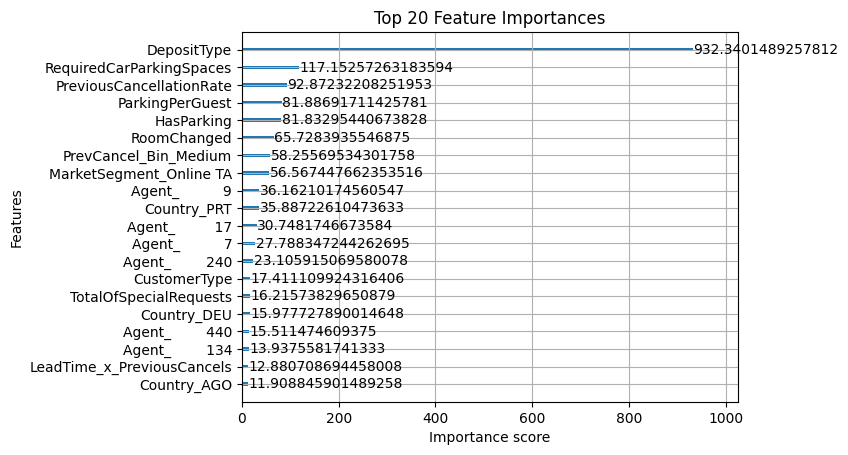

In [26]:

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    xgb,
    X,
    y,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1
)

print("\nCV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())